In [10]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt

In [11]:
df = pd.read_csv("trades_clean.csv", parse_dates=["created_time"])
df = df.sort_values(["ticker", "created_time"]).reset_index(drop=True)

WINDOW = 12

def build_hourly(group):
    group = group.set_index("created_time").sort_index()
    return group["yes_price"].resample("1h").last().ffill()

outcome_lookup = df.groupby("ticker")["outcome"].first().to_dict()

series_dict = {}
for ticker, group in df.groupby("ticker"):
    hourly = build_hourly(group)
    if len(hourly) >= WINDOW:
        series_dict[ticker] = hourly

In [12]:
tickers = np.array(list(series_dict.keys()))
np.random.seed(42)
np.random.shuffle(tickers)

split = int(len(tickers) * 0.8)
train_tickers = set(tickers[:split])
test_tickers = set(tickers[split:])

In [13]:
class KalshiDataset(Dataset):
    def __init__(self, tickers, series_dict, outcome_lookup, window):
        self.samples = []
        for ticker in tickers:
            prices = series_dict[ticker].values.astype(np.float32)
            outcome = outcome_lookup[ticker]
            for i in range(window, len(prices)):
                seq = prices[i - window:i]
                next_price = prices[i]
                self.samples.append((seq, next_price, outcome))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        seq, next_price, outcome = self.samples[idx]
        x = torch.FloatTensor(seq).unsqueeze(-1)
        return x, torch.FloatTensor([next_price]), torch.FloatTensor([outcome])

train_ds = KalshiDataset(train_tickers, series_dict, outcome_lookup, WINDOW)
test_ds = KalshiDataset(test_tickers, series_dict, outcome_lookup, WINDOW)
train_loader = DataLoader(train_ds, batch_size=64, shuffle=True)
test_loader = DataLoader(test_ds, batch_size=64, shuffle=False)

In [14]:
class KalshiLSTM(nn.Module):
    def __init__(self, input_size=1, hidden_size=64, num_layers=2, dropout=0.3):
        super().__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True, dropout=dropout)
        self.reg_head = nn.Sequential(nn.Linear(hidden_size, 32), nn.ReLU(), nn.Linear(32, 1))
        self.cls_head = nn.Sequential(nn.Linear(hidden_size, 32), nn.ReLU(), nn.Linear(32, 1), nn.Sigmoid())

    def forward(self, x):
        out, _ = self.lstm(x)
        h = out[:, -1, :]
        return self.reg_head(h), self.cls_head(h)

model = KalshiLSTM()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=5, factor=0.5)
mse_loss = nn.MSELoss()
bce_loss = nn.BCELoss()

In [20]:
EPOCHS = 50
train_losses, val_losses = [], []

for epoch in range(EPOCHS):
    model.train()
    train_loss = 0
    for x, y_price, y_outcome in train_loader:
        optimizer.zero_grad()
        price_pred, class_pred = model(x)
        loss = 0.5 * mse_loss(price_pred, y_price) + 0.5 * bce_loss(class_pred, y_outcome)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        train_loss += loss.item()

    model.eval()
    val_loss = 0
    with torch.no_grad():
        for x, y_price, y_outcome in test_loader:
            price_pred, class_pred = model(x)
            loss = 0.5 * mse_loss(price_pred, y_price) + 0.5 * bce_loss(class_pred, y_outcome)
            val_loss += loss.item()

    avg_train = train_loss / len(train_loader)
    avg_val = val_loss / len(test_loader)
    train_losses.append(avg_train)
    val_losses.append(avg_val)
    
    print(epoch)



0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49


In [21]:
model.eval()
price_preds, price_trues, class_preds, class_trues, rw_preds = [], [], [], [], []

with torch.no_grad():
    for x, y_price, y_outcome in test_loader:
        pp, cp = model(x)
        price_preds.extend(pp.squeeze().tolist())
        price_trues.extend(y_price.squeeze().tolist())
        class_preds.extend(cp.squeeze().tolist())
        class_trues.extend(y_outcome.squeeze().tolist())
        rw_preds.extend(x[:, -1, 0].tolist())

price_preds = np.array(price_preds)
price_trues = np.array(price_trues)
class_preds = np.array(class_preds)
class_trues = np.array(class_trues)
rw_preds = np.array(rw_preds)

rmse_lstm = np.sqrt(np.mean((price_preds - price_trues) ** 2))
rmse_rw = np.sqrt(np.mean((rw_preds - price_trues) ** 2))
brier_lstm = np.mean((class_preds - class_trues) ** 2)
brier_baseline = np.mean((price_trues - class_trues) ** 2)

print(f"Regression results:")
print(f"Random walk RMSE:{rmse_rw}")
print(f"LSTM RMSE:{rmse_lstm}")
print(f"Classification results:")
print(f"Baseline Brier:{brier_baseline}")
print(f"LSTM Brier:{brier_lstm}")

Regression results:
Random walk RMSE:0.04109637402209896
LSTM RMSE:0.04750096046283867
Classification results:
Baseline Brier:0.04721637865631946
LSTM Brier:0.0478603529430978


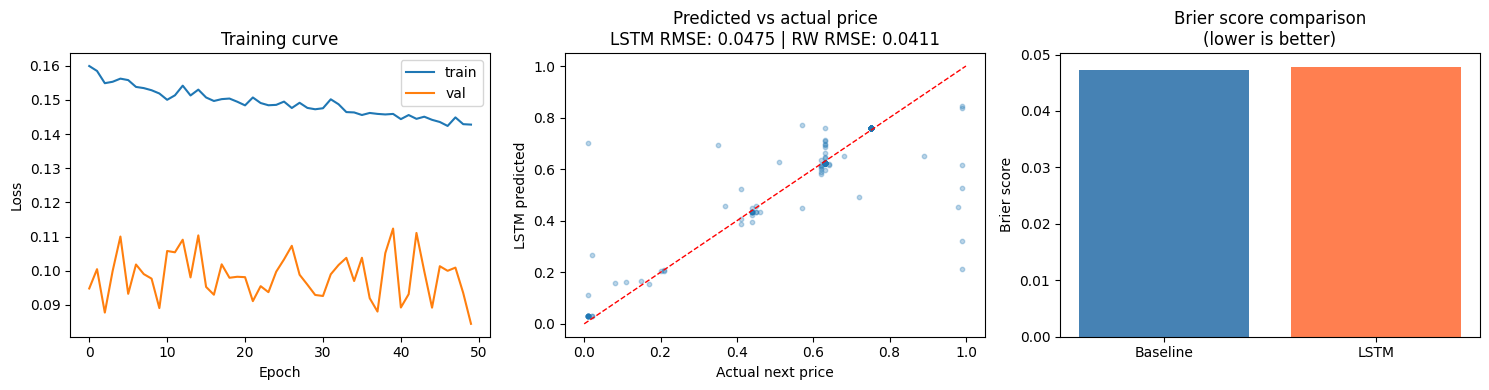

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(train_losses, label="train")
axes[0].plot(val_losses, label="val")
axes[0].set_title("Training curve")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()

axes[1].scatter(price_trues[:500], price_preds[:500], alpha=0.3, s=10)
axes[1].plot([0, 1], [0, 1], "r--", linewidth=1)
axes[1].set_title(f"Predicted vs actual price\nLSTM RMSE: {rmse_lstm:.4f} | RW RMSE: {rmse_rw:.4f}")
axes[1].set_xlabel("Actual next price")
axes[1].set_ylabel("LSTM predicted")

axes[2].bar(["Baseline", "LSTM"], [brier_baseline, brier_lstm], color=["steelblue", "coral"])
axes[2].set_title("Brier score comparison")
axes[2].set_ylabel("Brier score")

plt.tight_layout()
plt.savefig("lstm_results.png", dpi=150)
plt.show()